In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import tensorflow as tf
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import joblib
import os


2025-09-20 05:37:25.688851: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-20 05:37:25.740939: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-20 05:37:26.594778: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def c6_data():
    df = pd.read_csv('Fill-1.csv')
    print(df.shape)

    # 删除重复值
    df.drop_duplicates(inplace=True)
    print(df.shape)

    x = df.iloc[:, :2].values
    y = df.iloc[:, 2].values

    print(x.shape, y.shape)
    
    # 归一化
    scaler_x = StandardScaler()
    scaler_x.fit(x)
    x = scaler_x.transform(x)

    scaler_y = StandardScaler()
    y = y.reshape(-1, 1)  # Reshape y to have one feature
    scaler_y.fit(y)
    y = scaler_y.transform(y)

    # 划分数据集
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=666)

    return x_train, x_test, y_train, y_test, scaler_x, scaler_y

# 获取数据
x_train, x_test, y_train, y_test, scaler_x, scaler_y = c6_data()

# 保存处理后的数据在csv文件里
def save_data_to_csv(x_train, x_test, y_train, y_test):
    # 将数据转换为DataFrame
    df_x_train = pd.DataFrame(x_train)
    df_x_test = pd.DataFrame(x_test)
    df_y_train = pd.DataFrame(y_train)
    df_y_test = pd.DataFrame(y_test)

    # 保存到CSV文件
    df_x_train.to_csv('x_train_tl.csv', index=False)
    df_x_test.to_csv('x_test_tl.csv', index=False)
    df_y_train.to_csv('y_train_tl.csv', index=False)
    df_y_test.to_csv('y_test_tl.csv', index=False)

save_data_to_csv(x_train, x_test, y_train, y_test)


(169544, 3)
(135550, 3)
(135550, 2) (135550,)


In [3]:
# 假设每个样本有10个时间步长
sequence_length = 10

# 生成时间序列数据
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

# 创建训练和测试序列
x_train_seq = create_sequences(x_train, sequence_length)
x_test_seq = create_sequences(x_test, sequence_length)

# 调整 y_train 和 y_test 的形状以匹配序列
y_train_seq = y_train[sequence_length - 1:]
y_test_seq = y_test[sequence_length - 1:]

# 归一化数据
scaler = StandardScaler()

# 展平 x_train_seq 进行归一化
num_samples, sequence_length, num_features = x_train_seq.shape
x_train_flat = x_train_seq.reshape(-1, num_features)
x_train_scaled = scaler.fit_transform(x_train_flat).reshape(num_samples, sequence_length, num_features)

# 展平 x_test_seq 进行归一化
num_samples_test = x_test_seq.shape[0]
x_test_flat = x_test_seq.reshape(-1, num_features)
x_test_scaled = scaler.transform(x_test_flat).reshape(num_samples_test, sequence_length, num_features)


In [4]:
# 定义 LSTM 模型
model = Sequential()
model.add(LSTM(32, input_shape=(sequence_length, num_features), return_sequences=True))  # LSTM 层
model.add(LSTM(32))  # 额外的 LSTM 层
model.add(Dense(1))  # 输出层

# 编译模型
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error')

model_path = './lstmmodel/model_lstm_weight'
# 加载模型
if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("Model loaded from disk.")
else:
    print("Model file not found.")


2025-09-20 05:37:34.302218: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9613 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:3d:00.0, compute capability: 7.5


Model loaded from disk.


In [5]:
# Freeze the first LSTM layer
model.layers[0].trainable = False


In [6]:
# Compile the model with a lower learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mean_squared_error', metrics=['mae'])


In [8]:
# Fine-tune the model with new data
history = model.fit(x_train_scaled, y_train_seq, epochs=50, batch_size=200, validation_data=(x_test_scaled, y_test_seq))


Epoch 1/50


2024-10-29 06:13:58.864989: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2024-10-29 06:13:58.951881: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fd0a0768880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-10-29 06:13:58.951903: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080 Ti, Compute Capability 7.5
2024-10-29 06:13:58.956374: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 18/543 [..............................] - ETA: 1s - loss: 1.2235 - mae: 0.9325   

2024-10-29 06:13:59.085382: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


543/543 [==============================] - 5s 5ms/step - loss: 0.9110 - mae: 0.7919 - val_loss: 0.6915 - val_mae: 0.6896
Epoch 2/50
543/543 [==============================] - 2s 3ms/step - loss: 0.4812 - mae: 0.5765 - val_loss: 0.3072 - val_mae: 0.4564
Epoch 3/50
543/543 [==============================] - 2s 3ms/step - loss: 0.2583 - mae: 0.4039 - val_loss: 0.2374 - val_mae: 0.3764
Epoch 4/50
543/543 [==============================] - 2s 3ms/step - loss: 0.2161 - mae: 0.3516 - val_loss: 0.2080 - val_mae: 0.3384
Epoch 5/50
543/543 [==============================] - 2s 3ms/step - loss: 0.1915 - mae: 0.3209 - val_loss: 0.1862 - val_mae: 0.3131
Epoch 6/50
543/543 [==============================] - 2s 3ms/step - loss: 0.1724 - mae: 0.2997 - val_loss: 0.1691 - val_mae: 0.2943
Epoch 7/50
543/543 [==============================] - 2s 3ms/step - loss: 0.1579 - mae: 0.2837 - val_loss: 0.1565 - val_mae: 0.2808
Epoch 8/50
543/543 [==============================] - 2s 3ms/step - loss: 0.1471 - mae:

In [7]:
# 加载迁移学习后的模型
fine_tuned_model_path = './lstmtlmodel/model_lstmlt_weight_TL'
if os.path.exists(fine_tuned_model_path):
    model = tf.keras.models.load_model(fine_tuned_model_path)
    print("Fine-tuned model loaded from disk.")
else:
    print("Model file not found.")
    

Fine-tuned model loaded from disk.


In [8]:
# 预测并计算额外的指标
y_pred = model.predict(x_test_scaled)

# 计算均方误差 (MSE)
mse = mean_squared_error(y_test_seq, y_pred)
print(f"MSE: {mse}")

# 计算均方根误差 (RMSE)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse}")

# 计算平均绝对误差 (MAE)
mae = mean_absolute_error(y_test_seq, y_pred)
print(f"MAE: {mae}")

# 计算 R²
r2 = r2_score(y_test_seq, y_pred)
print(f"R²: {r2}")


 96/847 [==>...........................] - ETA: 1s

2025-09-20 05:37:50.663391: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


847/847 [==============================] - 2s 2ms/step
MSE: 0.06920077973992383
RMSE: 0.26306041081835907
MAE: 0.1605391482800232
R²: 0.9315231401006044


In [45]:
model.save('lstmtlmodel.h5')

/root/miniconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [46]:
# 保存迁移学习后的模型
fine_tuned_model_path = './lstmtlmodel/model_lstmlt_weight_TL'
model.save(fine_tuned_model_path)
print("Fine-tuned model saved to disk.")


INFO:tensorflow:Assets written to: ./lstmtlmodel/model_lstmlt_weight_TL/assets


INFO:tensorflow:Assets written to: ./lstmtlmodel/model_lstmlt_weight_TL/assets


Fine-tuned model saved to disk.


损失图已保存到: tl_lstm_fig/lstm_loss_plot.png
局部放大损失图已保存到: tl_lstm_fig/zoom_loss_plot.png


/tmp/ipykernel_834/1398553602.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


结合图已保存到: tl_lstm_fig/lstm_combined_plot.png


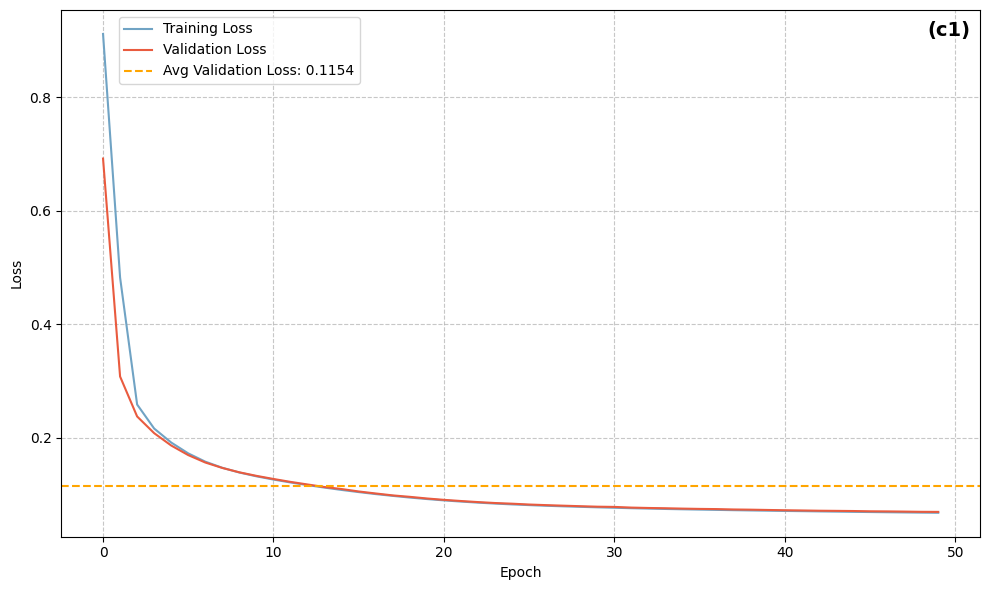

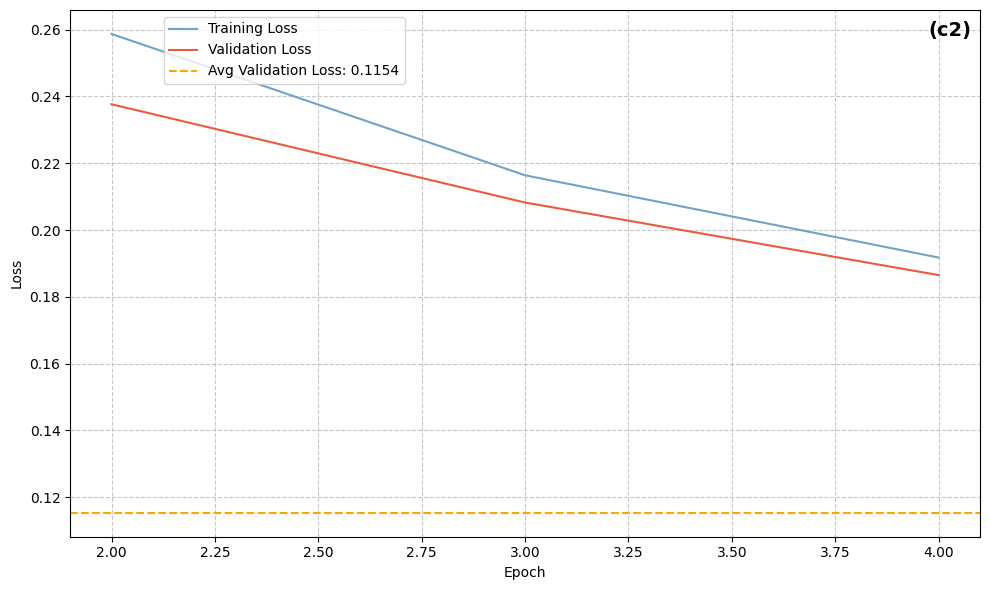

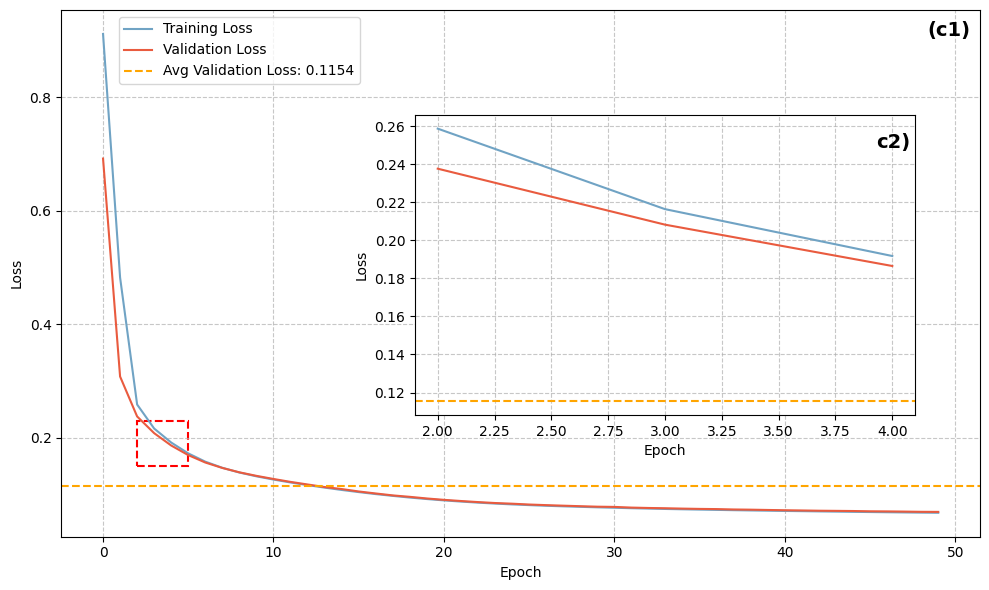

In [13]:
# # 假设 train_loss_list 和 val_loss_list 是 LSTM 模型的训练和验证损失
# train_loss_list = history.history['loss']
# val_loss_list = history.history['val_loss']

# # 计算平均验证损失
# avg_val_loss = np.mean(val_loss_list)

# # 自定义缩放范围
# zoom_epoch_start = 2
# zoom_epoch_end = 5

# # 自定义矩形高度
# rect_y_min = 0.15
# rect_y_max = 0.23

# # 创建保存图像的文件夹
# folder_name = "tl_lstm_fig"
# os.makedirs(folder_name, exist_ok=True)

# # 绘制损失图
# fig, ax1 = plt.subplots(figsize=(10, 6))
# ax1.plot(train_loss_list, color='#70A3C4', label='Training Loss')
# ax1.plot(val_loss_list, color='#E95B3F', label='Validation Loss')
# ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
# ax1.grid(True, linestyle='--', alpha=0.7)
# ax1.text(0.99, 0.98, '(c1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
# plt.tight_layout()
# loss_file_path = os.path.join(folder_name, 'lstm_loss_plot.png')
# plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
# print(f"损失图已保存到: {loss_file_path}")

# # 绘制局部放大图
# fig, ax2 = plt.subplots(figsize=(10, 6))
# ax2.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss_list[zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
# ax2.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss_list[zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
# ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
# ax2.legend(loc='upper left', bbox_to_anchor=(0.095, 1), bbox_transform=ax2.transAxes)
# ax2.set_xlabel('Epoch')
# ax2.set_ylabel('Loss')
# ax2.grid(True, linestyle='--', alpha=0.7)
# ax2.text(0.99, 0.98, '(c2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
# plt.tight_layout()
# zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
# plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
# print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# # 绘制结合图，将局部放大图嵌入到主图中
# fig, ax1 = plt.subplots(figsize=(10, 6))
# ax1.plot(train_loss_list, color='#70A3C4', label='Training Loss')
# ax1.plot(val_loss_list, color='#E95B3F', label='Validation Loss')
# ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
# ax1.set_xlabel('Epoch')
# ax1.set_ylabel('Loss')
# ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
# ax1.grid(True, linestyle='--', alpha=0.7)
# ax1.text(0.99, 0.98, '(c1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# # 嵌入放大损失图
# inset_ax = fig.add_axes([0.42, 0.30, 0.5, 0.5])  # [left, bottom, width, height]
# inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss_list[zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
# inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss_list[zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
# inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')  # 添加平均值线
# inset_ax.set_xlabel('Epoch')
# inset_ax.set_ylabel('Loss')
# inset_ax.grid(True, linestyle='--', alpha=0.7)
# inset_ax.text(0.99, 0.94, 'c2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# # 添加红色虚线框
# rect = plt.Rectangle((zoom_epoch_start, rect_y_min), 
#                      zoom_epoch_end - zoom_epoch_start, 
#                      rect_y_max - rect_y_min, 
#                      edgecolor='red', linestyle='--', linewidth=1.5, facecolor='none', transform=ax1.transData)
# ax1.add_patch(rect)

# plt.tight_layout()
# combined_file_path = os.path.join(folder_name, 'lstm_combined_plot.png')
# plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
# print(f"结合图已保存到: {combined_file_path}")

# # 显示图表
# plt.show()

825/825 [==============================] - 2s 2ms/step


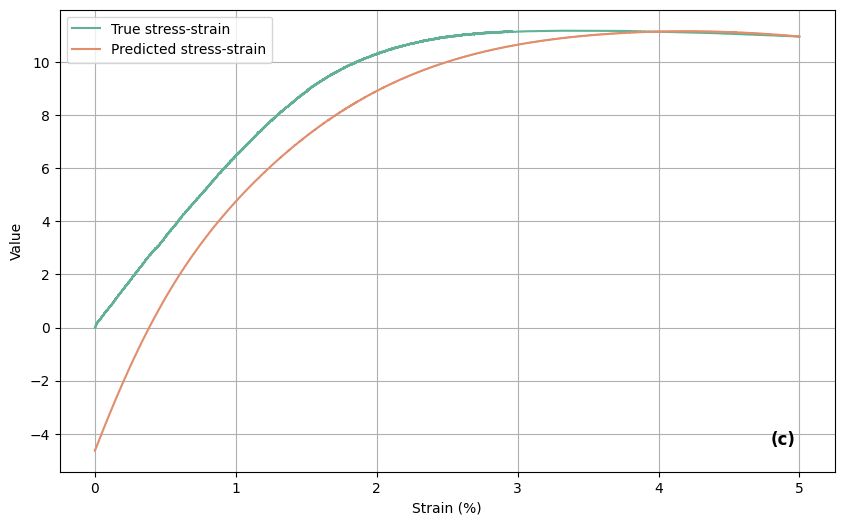

预测曲线与实际曲线已保存并显示: tl_lstm_fig/prediction/predicted_vs_true_curve.png


In [22]:
# 读取新数据
file_name = '60-p.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
x_new = df_new_data.iloc[:, :2].values  # 假设前两列是特征
y_true = df_new_data.iloc[:, 2].values  # 第三列为真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值

# 归一化特征
x_new_scaled = scaler_x.transform(x_new)

# 创建时间序列数据
sequence_length = 10
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值逆归一化
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(y_true), len(y_pred))
y_true_truncated = y_true[sequence_length - 1:sequence_length - 1 + min_length]
y_pred_truncated = y_pred[:min_length]
strain_truncated = strain[sequence_length - 1:sequence_length - 1 + min_length]

# 截断到应变小于或等于2.7
valid_indices = strain_truncated <= 5
strain_truncated = strain_truncated[valid_indices]
y_true_truncated = y_true_truncated[valid_indices]
y_pred_truncated = y_pred_truncated[valid_indices]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_truncated, y_true_truncated, label='True stress-strain', color='#62B197')
plt.plot(strain_truncated, y_pred_truncated, label='Predicted stress-strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Value')
plt.legend()
# plt.title('True vs Predicted Values')
plt.grid(True)

# 在右下角添加文本 (b1)
plt.text(0.95, 0.05, '(c)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', ha='right', va='bottom')


# 保存图像
folder_path = os.path.join('tl_lstm_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)
save_path = os.path.join(folder_path, 'predicted_vs_true_curve.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"预测曲线与实际曲线已保存并显示: {save_path}")


825/825 [==============================] - 1s 2ms/step


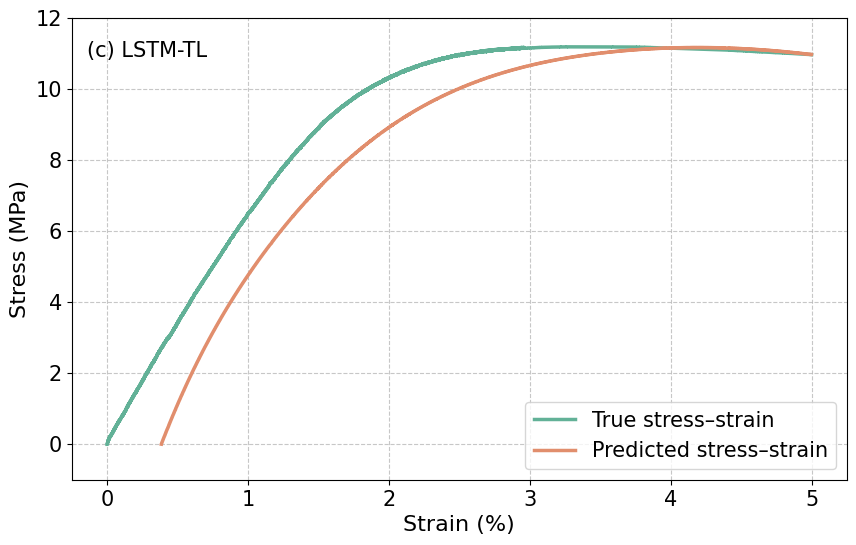

预测曲线与实际曲线已保存并显示: tl_lstm_fig/prediction/predicted_vs_true_curve.png


In [45]:
# 读取新数据
file_name = '60-p.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
x_new = df_new_data.iloc[:, :2].values  # 假设前两列是特征
y_true = df_new_data.iloc[:, 2].values  # 第三列为真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值

# 归一化特征
x_new_scaled = scaler_x.transform(x_new)

# 创建时间序列数据
sequence_length = 10
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值逆归一化
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(y_true), len(y_pred))
y_true_truncated = y_true[sequence_length - 1:sequence_length - 1 + min_length]
y_pred_truncated = y_pred[:min_length]
strain_truncated = strain[sequence_length - 1:sequence_length - 1 + min_length]

# 根据应变阈值截断（此处 ≤5，可按需改）
valid_indices = strain_truncated <= 5
strain_truncated = strain_truncated[valid_indices]
y_true_truncated = y_true_truncated[valid_indices]
y_pred_truncated = y_pred_truncated[valid_indices]

# 进一步筛选：只保留预测值 >= 1 的部分
strain_display = strain_truncated
y_true_display = y_true_truncated
y_pred_display = y_pred_truncated.copy()
y_pred_display[y_pred_display < 0] = np.nan

# —— 绘图（放大字号、线宽，并加模型名 LSTM） ——
plt.figure(figsize=(10, 6))
plt.plot(strain_display, y_true_display, label='True stress–strain', color='#62B197', linewidth=2.5)
plt.plot(strain_display, y_pred_display, label='Predicted stress–strain', color='#E18E6D', linewidth=2.5)
plt.ylim(-1, 12)

# 坐标轴与刻度字号
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 图例与网格
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 右下角角标（你的原设置）
plt.text(0.02, 0.95, '(c) LSTM-TL', transform=plt.gca().transAxes,
         fontsize=15, ha='left', va='top')

# 保存图像（高清）
folder_path = os.path.join('tl_lstm_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)
save_path = os.path.join(folder_path, 'predicted_vs_true_curve.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示并关闭
plt.show()
plt.close()

print(f"预测曲线与实际曲线已保存并显示: {save_path}")


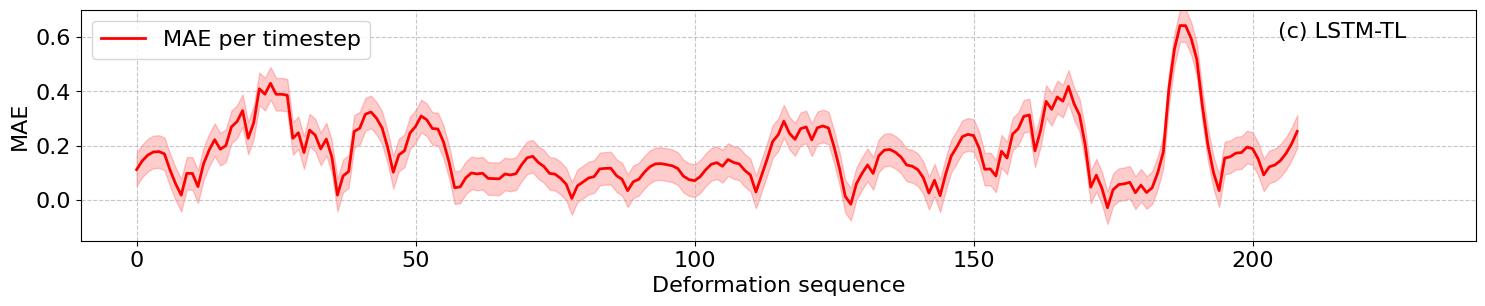

MAE per timestep plot saved and displayed: ./tl_lstm_fig/mae_per_timestep.png


In [9]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator

# 计算每个时间步的 MAE
mae_per_timestep = np.abs(y_test_seq - y_pred).mean(axis=1)

# 采样数据以减少密度（例如，每隔250个点取一个）
sampling_rate = 130
mae_sampled = mae_per_timestep[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)

# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per timestep', color='red', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.06  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='red', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=16)

# 在右上角添加文本 (a)
plt.text(0.95, 0.95, '(c) LSTM-TL', fontsize=16, ha='right', va='top', transform=plt.gca().transAxes)

plt.xlabel('Deformation sequence', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.15, 0.7)
plt.xlim(-10, 240)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.2))

# 保存图像
mae_timestep_path = './tl_lstm_fig/mae_per_timestep.png'
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per timestep plot saved and displayed: {mae_timestep_path}")

[LSTM-TL] 建议范围 => vmin=4.04083e-06, vmax=16.0966
误差等高线图已保存为: tl_lstm_fig/lstm_tl_error_contour_log_scale_formatted.png


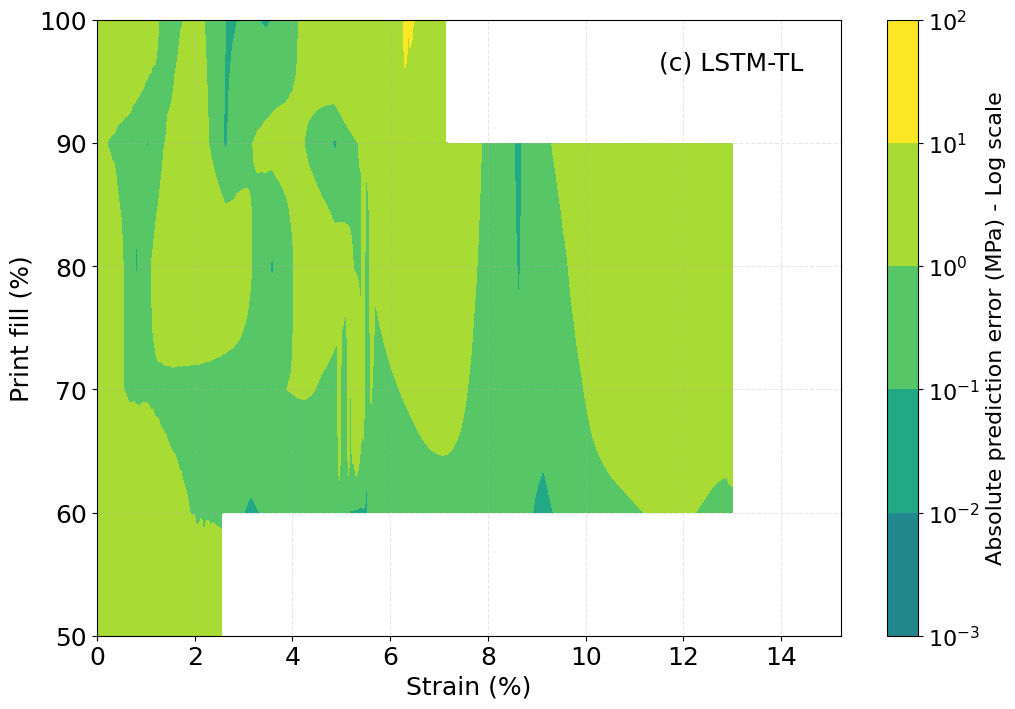

In [10]:

# 四图统一色条范围（LogNorm 要求 vmin > 0）
GLOBAL_VMIN = 1.13126e-06
GLOBAL_VMAX = 28.4838
# ===== 误差等高线（LSTM-TL）—— 两步线性插值 + LogNorm + 100级 contourf（无黑线与数值） =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import matplotlib.colors as mcolors

# 1) 读取评估数据并预测（复用训练时的 scaler 与 LSTM 模型）
EVALUATION_DATA_PATH = 'Fill-1.csv'
df_eval = pd.read_csv(EVALUATION_DATA_PATH).drop_duplicates()

x_eval = df_eval.iloc[:, :2].values
y_eval = df_eval.iloc[:, 2].values.reshape(-1, 1)

x_eval_scaled = scaler_x.transform(x_eval)

# 序列化：保持与训练/预测一致的 sequence_length
try:
    sequence_length
except NameError:
    sequence_length = 10

def create_sequences(data: np.ndarray, seq_length: int) -> np.ndarray:
    seqs = []
    for i in range(len(data) - seq_length + 1):
        seqs.append(data[i:i + seq_length])
    return np.array(seqs)

x_eval_seq = create_sequences(x_eval_scaled, sequence_length)

# 进行预测（与 60-p 的用法一致）
y_pred_scaled = model.predict(x_eval_seq, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 对齐真值与输入特征：序列预测对应最后一个时间步
y_true_aligned = y_eval[sequence_length - 1:].flatten()
angle_original = x_eval[sequence_length - 1:, 0].astype(float)
strain_original = x_eval[sequence_length - 1:, 1].astype(float)

absolute_error = np.abs(y_pred - y_true_aligned)

# 2) 构造 df_plot 并执行“两步一维线性插值”（沿应变→沿参数）
df_plot = pd.DataFrame({
    'Strain': strain_original,
    'Angle': angle_original,
    'Error': absolute_error.astype(float)
})
# 导出误差点表 CSV
out_dir = os.path.join('error_points')
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'lstm_tl_points.csv'), index=False)

# 与组图保持一致：按参数取整分组（1单位）
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].dropna().unique())

# 统一网格
grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

# 第一步：每个角度组内沿应变插值
aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f_strain = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f_strain(strain_common)

# 第二步：对每个应变点沿参数轴插值
final_grid_error = np.full((len(angle_grid_dense), len(strain_common)), np.nan)
for i in range(len(strain_common)):
    current_errors = []
    valid_angles = []
    for ang in unique_angles:
        if ang in aligned_errors:
            current_errors.append(aligned_errors[ang][i])
            valid_angles.append(ang)
    if len(valid_angles) > 1:
        current_errors = np.array(current_errors, dtype=float)
        valid_angles = np.array(valid_angles, dtype=float)
        mask = ~np.isnan(current_errors)
        if np.sum(mask) > 1:
            f_angle = interp1d(valid_angles[mask], current_errors[mask], bounds_error=False, fill_value=np.nan)
            final_grid_error[:, i] = f_angle(angle_grid_dense)

# 3) 绘制：100级 contourf + LogNorm（无黑线与数值）
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))

target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
final_grid_error_masked = np.ma.masked_invalid(final_grid_error)

# 动态 LogNorm：最小正误差到最大误差
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
final_grid_error_masked = np.ma.masked_less_equal(final_grid_error, 0)  # 遮罩 ≤0
norm = mcolors.LogNorm(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)              # 统一色条
contour = ax.contourf(target_strain, target_angle, final_grid_error_masked,
                      levels=100, cmap='viridis', norm=norm)
print(f"[LSTM-TL] 建议范围 => vmin={min_error_for_log:.6g}, vmax={df_plot['Error'].max():.6g}")


# 颜色条与字体
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16)
cbar.ax.tick_params(labelsize=16)

# 轴与网格
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print fill (%)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18)

# 角标
ax.text(0.95, 0.95, '(c) LSTM-TL', transform=ax.transAxes, fontsize=18, ha='right', va='top')

# 保存
out_dir = os.path.join('tl_lstm_fig')
os.makedirs(out_dir, exist_ok=True)
output_filename = os.path.join(out_dir, 'lstm_tl_error_contour_log_scale_formatted.png')
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"误差等高线图已保存为: {output_filename}")
plt.show()


In [9]:
# 计算 60-p.csv 的 MAE / RMSE / R²（全量与 Strain≤5）并保存
import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf

# 输出目录
out_dir = os.path.join('tl_lstm_fig', 'prediction')
os.makedirs(out_dir, exist_ok=True)

# 读取未见测试集
df_test = pd.read_csv('60-p.csv')
x_new = df_test.iloc[:, :2].values     # [Angle, Strain]
y_true = df_test.iloc[:, 2].values     # Stress
strain = df_test.iloc[:, 1].values     # Strain

# 使用迁移学习阶段的 scaler 做归一化
x_new_scaled = scaler_x.transform(x_new)

# 序列长度（与训练一致）
try:
    sequence_length
except NameError:
    sequence_length = 10

# 构造序列（若上文未定义，给出兜底）
def _create_sequences(data, seq_len):
    seqs = []
    for i in range(len(data) - seq_len + 1):
        seqs.append(data[i:i + seq_len])
    return np.array(seqs)

x_new_seq = _create_sequences(x_new_scaled, sequence_length)

# 准备并加载迁移学习后的模型（若当前会话未加载）
try:
    _ = model
except NameError:
    fine_tuned_model_path = './lstmtlmodel/model_lstmlt_weight_TL'
    model = tf.keras.models.load_model(fine_tuned_model_path)

# 预测并反归一化
y_pred_scaled = model.predict(x_new_seq, verbose=0)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# 对齐真实值与应变（序列预测对应末端一步）
pred_len = len(y_pred)
y_true_aligned = y_true[sequence_length - 1:sequence_length - 1 + pred_len]
strain_aligned = strain[sequence_length - 1:sequence_length - 1 + pred_len]

# 全量指标
mse_all = mean_squared_error(y_true_aligned, y_pred)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(y_true_aligned, y_pred)
r2_all = r2_score(y_true_aligned, y_pred)

# 阈值内（与图一致）：Strain ≤ 5
mask = strain_aligned <= 5
y_true_thr = y_true_aligned[mask]
y_pred_thr = y_pred[mask]

mse_thr = mean_squared_error(y_true_thr, y_pred_thr) if len(y_true_thr) > 0 else np.nan
rmse_thr = np.sqrt(mse_thr) if np.isfinite(mse_thr) else np.nan
mae_thr = mean_absolute_error(y_true_thr, y_pred_thr) if len(y_true_thr) > 0 else np.nan
r2_thr = r2_score(y_true_thr, y_pred_thr) if len(y_true_thr) > 1 else np.nan

# 打印结果
print('=== 60-p.csv metrics (LSTM-TL) ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
if np.isfinite(mae_thr):
    print(f'Strain≤5     -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')
else:
    print('Strain≤5     -> 无有效样本')

# 保存 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<=5',  'MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join(out_dir, '60-p_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')


=== 60-p.csv metrics (LSTM-TL) ===
All samples   -> MAE=0.8426, RMSE=1.2541, R²=0.7582
Strain≤5     -> MAE=1.1729, RMSE=1.5926, R²=0.7612
Metrics saved to: tl_lstm_fig/prediction/60-p_metrics.csv
